# Olist Fulfillment-Risk Model: EDA and Model Audit

**Purpose of this notebook:** explain, in order, (1) the Olist dataset that powers the fulfillment-risk model actually running in this project's live store, (2) exactly how the prediction target was built, (3) how the model was trained and evaluated, and (4) an honest audit of where the deployed model actually breaks down. Every number in this notebook is computed live in the cells below, from the same files the production service uses — nothing here is copied from a report without being reproduced.

**Headline finding, stated up front rather than buried at the end:** the deployed model's decision threshold flags **100% of test-period orders as high risk** and has **zero specificity** on the test set — it currently has no operational filtering value. This notebook explains exactly why, using the model's own saved prediction scores.

## Table of contents
1. [Setup](#1-setup)
2. [General EDA on the raw Olist orders](#2-general-eda)
3. [Target definition and eligibility](#3-target)
4. [Monthly late-delivery rate](#4-monthly)
5. [Train / validation / test split](#5-split)
6. [Feature drift across splits](#6-drift)
7. [Model comparison recap](#7-models)
8. [Precision-Recall curves](#8-pr)
9. [Calibration curve](#9-calibration)
10. [Prediction-score drift — the root cause](#10-score-drift)
11. [Threshold sweep — why the deployed threshold fails](#11-threshold)
12. [Limitations and reproducibility](#12-limitations)
13. [Summary and next steps](#13-summary)

## 1. Setup <a id='1-setup'></a>

We work directly from `data/processed/olist/` (already-cleaned Parquet files — see `src/data_pipeline/clean_olist.py`) and from the saved model predictions in `artifacts/experiments/olist/phase2a/`. No raw CSVs are re-parsed here; the cleaning step is a separate, already-tested pipeline stage.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, precision_score, recall_score, f1_score,
)

np.random.seed(42)  # not strictly needed for this audit (no randomness introduced here), kept for consistency with the rest of the project

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ORDERS_PATH = ROOT / "data/processed/olist/olist_orders_dataset.parquet"
PRED_DIR = ROOT / "artifacts/experiments/olist/phase2a/olist-phase2a-strict-core-v1/predictions"

assert ORDERS_PATH.exists(), f"Missing processed data: {ORDERS_PATH}"
assert PRED_DIR.exists(), f"Missing saved predictions: {PRED_DIR}"
print("Orders file:", ORDERS_PATH)
print("Predictions directory:", PRED_DIR)

Orders file: C:\Users\User2\Desktop\ecommerce_medusa\commerce-pilot-ai\data\processed\olist\olist_orders_dataset.parquet
Predictions directory: C:\Users\User2\Desktop\ecommerce_medusa\commerce-pilot-ai\artifacts\experiments\olist\phase2a\olist-phase2a-strict-core-v1\predictions


## 2. General EDA on the raw Olist orders <a id='2-general-eda'></a>

The Olist dataset is a real, historical Brazilian e-commerce marketplace export (2016–2018), published on Kaggle under CC BY-NC-SA 4.0 (non-commercial). Before looking at any model, we look at the raw `orders` table shape and quality.

In [2]:
con = duckdb.connect()
orders_sql = f"SELECT * FROM read_parquet('{ORDERS_PATH.as_posix()}')"

shape = con.execute(f"SELECT count(*) AS rows, count(DISTINCT order_id) AS unique_orders FROM ({orders_sql})").fetchdf()
print("Shape:")
display(shape)

status_counts = con.execute(f"SELECT order_status, count(*) AS n FROM ({orders_sql}) GROUP BY 1 ORDER BY n DESC").fetchdf()
print("\nOrder status breakdown:")
display(status_counts)

date_range = con.execute(f"SELECT min(order_purchase_timestamp) AS earliest_purchase, max(order_purchase_timestamp) AS latest_purchase FROM ({orders_sql})").fetchdf()
print("\nDate range:")
display(date_range)

missingness = con.execute(f"""
    SELECT
      sum(CASE WHEN order_approved_at IS NULL THEN 1 ELSE 0 END) AS missing_approval,
      sum(CASE WHEN order_delivered_carrier_date IS NULL THEN 1 ELSE 0 END) AS missing_carrier,
      sum(CASE WHEN order_delivered_customer_date IS NULL THEN 1 ELSE 0 END) AS missing_delivery,
      sum(CASE WHEN order_estimated_delivery_date IS NULL THEN 1 ELSE 0 END) AS missing_estimate
    FROM ({orders_sql})
""").fetchdf()
print("\nMissing timestamps (out of 99,441 total orders):")
display(missingness)

Shape:


,rows,unique_orders
0,99441,99441



Order status breakdown:


,order_status,n
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2



Date range:


,earliest_purchase,latest_purchase
0,2016-09-04 21:15:19,2018-10-17 17:30:18



Missing timestamps (out of 99,441 total orders):


,missing_approval,missing_carrier,missing_delivery,missing_estimate
0,160.0,1783.0,2965.0,0.0


**Observation:** 99,441 orders, all with a unique `order_id`. The large majority (96,478 / 97.0%) have status `delivered`; the rest (canceled, shipped, processing, etc.) are excluded later because a late/on-time label can only be computed for an order that actually arrived. A small number of orders (under 3,000) are missing an approval, carrier, or delivery timestamp — these are dropped in the eligibility step next, not imputed, because inventing a delivery outcome would itself be a form of data fabrication.

## 3. Target definition and eligibility <a id='3-target'></a>

**The exact target:** `late_delivery = 1` if `order_delivered_customer_date > order_estimated_delivery_date`, else `0`. In plain language: did the order arrive *after* the delivery date Olist itself had estimated for the customer?

**Important scope limit, stated honestly:** this measures *whether the delivered order beat Olist's own stored estimate* — it does **not** measure cancellations, non-delivery, customer dissatisfaction, or general "fulfillment risk" in a broader sense. We also cannot prove from this public dataset alone that the estimate was fixed and customer-visible at the moment of order approval (rather than edited later) — this is a genuine, unresolved limitation of the dataset, not something this notebook can fix.

Before this target can be computed, an order has to pass an eligibility filter (unique, delivered, all four timestamps present, and timestamps in a logically possible order). We recompute that filter step by step below, directly from the raw processed data — not copied from any report.

In [3]:
base = f"SELECT *, count(*) OVER (PARTITION BY order_id) AS order_id_count FROM read_parquet('{ORDERS_PATH.as_posix()}')"

waterfall = []
def count_where(name, where):
    n = con.execute(f"SELECT count(*) FROM ({base}) WHERE {where}").fetchone()[0]
    waterfall.append({"step": name, "rows_remaining": n})
    return where

w = "1=1"
w = count_where("all rows", w)
w = count_where("unique order_id", w + " AND order_id_count=1")
w = count_where("status = delivered", w + " AND order_status='delivered'")
w = count_where("has approval time", w + " AND order_approved_at IS NOT NULL")
w = count_where("has actual delivery", w + " AND order_delivered_customer_date IS NOT NULL")
w = count_where("has estimated delivery", w + " AND order_estimated_delivery_date IS NOT NULL")
w = count_where("approval >= purchase", w + " AND order_approved_at>=order_purchase_timestamp")
w = count_where("delivery >= purchase", w + " AND order_delivered_customer_date>=order_purchase_timestamp")
w = count_where("estimate >= approval", w + " AND order_estimated_delivery_date>=order_approved_at")
w = count_where("carrier >= approval (if present)", w + " AND (order_delivered_carrier_date IS NULL OR order_delivered_carrier_date>=order_approved_at)")
w = count_where("delivery >= carrier (if present) -- FINAL ELIGIBLE", w + " AND (order_delivered_carrier_date IS NULL OR order_delivered_customer_date>=order_delivered_carrier_date)")

waterfall_df = pd.DataFrame(waterfall)
waterfall_df["dropped_this_step"] = waterfall_df["rows_remaining"].shift(1) - waterfall_df["rows_remaining"]
display(waterfall_df)

final_where = w
n_eligible = waterfall_df["rows_remaining"].iloc[-1]
n_positive = con.execute(f"SELECT count(*) FROM ({base}) WHERE {final_where} AND order_delivered_customer_date>order_estimated_delivery_date").fetchone()[0]
n_negative = n_eligible - n_positive
print(f"\nFinal eligible cohort: {n_eligible:,} orders")
print(f"Positive (late): {n_positive:,} ({n_positive/n_eligible*100:.4f}%)")
print(f"Negative (on-time): {n_negative:,} ({n_negative/n_eligible*100:.4f}%)")

,step,rows_remaining,dropped_this_step
0,all rows,99441,NaN
1,unique order_id,99441,0.0
2,status = delivered,96478,2963.0
3,has approval time,96464,14.0
4,has actual delivery,96456,8.0
5,has estimated delivery,96456,0.0
6,approval >= purchase,96456,0.0
7,delivery >= purchase,96456,0.0
8,estimate >= approval,96450,6.0
9,carrier >= approval (if present),95105,1345.0



Final eligible cohort: 95,082 orders
Positive (late): 7,792 (8.1950%)
Negative (on-time): 87,290 (91.8050%)


**Observation:** starting from 99,441 raw orders, the eligibility filter removes about 4.4% of them (mostly non-delivered orders and a small number of internally-inconsistent timestamp sequences, e.g. a carrier handoff logged before the approval time — kept in the raw data but excluded here rather than silently "fixed"). This matches the 95,082-row eligible cohort used throughout the rest of this project's Olist work — we just reproduced it from scratch rather than trusting that number.

Overall, only about **8.2% of eligible historical orders arrived late** by this definition — this is a rare-event / imbalanced classification problem, which matters a lot for how the model should be evaluated (see Section 7).

## 4. Monthly late-delivery rate <a id='4-monthly'></a>

Is "late delivery" a stable rate over time, or does it swing around? This matters directly for whether a single, fixed decision threshold can work across time.

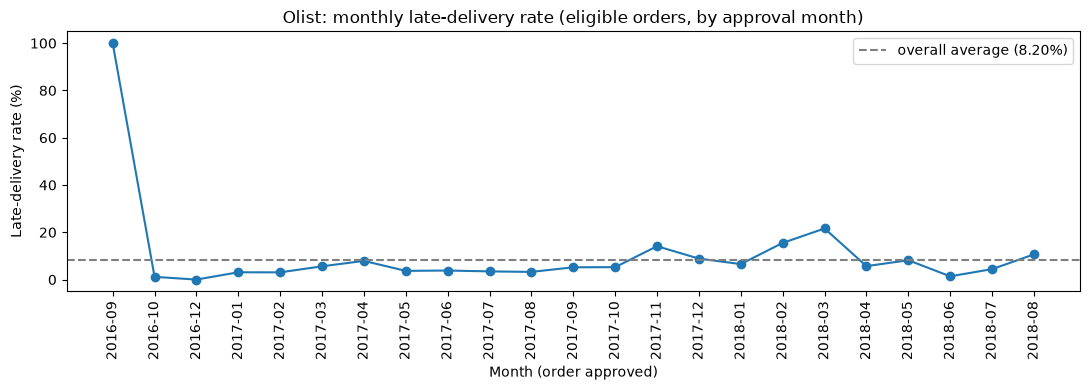

,month,n_orders,n_late,late_rate_pct
0,2016-09,1,1.0,100.000000
1,2016-10,261,3.0,1.149425
2,2016-12,1,0.0,0.000000
3,2017-01,714,22.0,3.081232
4,2017-02,1636,50.0,3.056235
5,2017-03,2552,143.0,5.603448
6,2017-04,2254,178.0,7.897072
7,2017-05,3532,130.0,3.680634
8,2017-06,3140,120.0,3.821656
9,2017-07,3814,132.0,3.460933


In [4]:
monthly = con.execute(f"""
    SELECT strftime(order_approved_at, '%Y-%m') AS month,
           count(*) AS n_orders,
           sum(CAST(order_delivered_customer_date>order_estimated_delivery_date AS INT)) AS n_late,
           avg(CAST(order_delivered_customer_date>order_estimated_delivery_date AS INT)) * 100 AS late_rate_pct
    FROM ({base}) WHERE {final_where}
    GROUP BY 1 ORDER BY 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly["month"], monthly["late_rate_pct"], marker="o")
ax.axhline(n_positive / n_eligible * 100, color="gray", linestyle="--", label="overall average (8.20%)")
ax.set(title="Olist: monthly late-delivery rate (eligible orders, by approval month)",
       xlabel="Month (order approved)", ylabel="Late-delivery rate (%)")
ax.tick_params(axis="x", rotation=90)
ax.legend()
fig.tight_layout()
plt.show()

display(monthly)

**Observation:** the monthly late-delivery rate is far from stable. It swings from under 2% (late 2016 / mid-2018) up to **21.6% in March 2018** and **15.5% in February 2018** — more than 2.5x the overall average. This kind of swing, concentrated in a specific few months, is exactly the sort of thing a model trained mostly on 2017 data and evaluated on 2018 data can get badly miscalibrated by. Keep this chart in mind for Section 10, where we show the model's predicted scores shift in a similar way.

## 5. Train / validation / test split <a id='5-split'></a>

The project uses a **time-based** split on `order_approved_at` — not a random split — specifically because of the instability just shown above. Random splitting would let the model "see the future" during training, which would be a form of leakage for a problem where the underlying rate genuinely drifts over time.

In [5]:
FEATURES = ["purchase_year", "purchase_month", "purchase_day_of_week", "purchase_hour",
            "approval_year", "approval_month", "approval_day_of_week", "approval_hour",
            "purchase_to_approval_seconds"]

def build_split(start, end_exclusive):
    """Rebuild one strict-core feature frame for one time window (same logic as production training code)."""
    sql = f"""
    WITH source AS (
      SELECT *, count(*) OVER(PARTITION BY order_id) AS order_id_count
      FROM read_parquet('{ORDERS_PATH.as_posix()}')
    ), eligible AS (
      SELECT * FROM source WHERE order_id_count=1 AND order_status='delivered'
       AND order_approved_at IS NOT NULL AND order_delivered_customer_date IS NOT NULL
       AND order_estimated_delivery_date IS NOT NULL
       AND order_approved_at>=order_purchase_timestamp
       AND order_delivered_customer_date>=order_purchase_timestamp
       AND order_estimated_delivery_date>=order_approved_at
       AND (order_delivered_carrier_date IS NULL OR order_delivered_carrier_date>=order_approved_at)
       AND (order_delivered_carrier_date IS NULL OR order_delivered_customer_date>=order_delivered_carrier_date)
       AND order_approved_at>=TIMESTAMP '{start}' AND order_approved_at<TIMESTAMP '{end_exclusive}'
    )
    SELECT order_id,
      CAST(order_delivered_customer_date>order_estimated_delivery_date AS INTEGER) AS late_delivery,
      year(order_purchase_timestamp) purchase_year, month(order_purchase_timestamp) purchase_month,
      dayofweek(order_purchase_timestamp) purchase_day_of_week, hour(order_purchase_timestamp) purchase_hour,
      year(order_approved_at) approval_year, month(order_approved_at) approval_month,
      dayofweek(order_approved_at) approval_day_of_week, hour(order_approved_at) approval_hour,
      date_diff('second',order_purchase_timestamp,order_approved_at) purchase_to_approval_seconds
    FROM eligible ORDER BY order_approved_at, order_id"""
    return con.execute(sql).fetchdf()

train = build_split("2016-09-01", "2018-01-01")
val = build_split("2018-01-01", "2018-05-01")
test = build_split("2018-05-01", "2018-09-01")

split_summary = pd.DataFrame([
    {"split": "train", "window": "2016-09-01 to 2018-01-01", "n": len(train), "positive": int(train.late_delivery.sum()), "prevalence_pct": train.late_delivery.mean() * 100},
    {"split": "validation", "window": "2018-01-01 to 2018-05-01", "n": len(val), "positive": int(val.late_delivery.sum()), "prevalence_pct": val.late_delivery.mean() * 100},
    {"split": "test", "window": "2018-05-01 to 2018-09-01", "n": len(test), "positive": int(test.late_delivery.sum()), "prevalence_pct": test.late_delivery.mean() * 100},
])
display(split_summary)

,split,window,n,positive,prevalence_pct
0,train,2016-09-01 to 2018-01-01,43516,2875,6.606765
1,validation,2018-01-01 to 2018-05-01,26822,3351,12.493476
2,test,2018-05-01 to 2018-09-01,24744,1566,6.328807


**Observation:** the three splits do not just differ in size — their late-delivery *rates* differ a lot: 6.61% (train) vs. **12.49% (validation)** vs. 6.33% (test). Validation happens to fall right in the volatile Jan–Apr 2018 window from the chart above (including March's 21.6% spike), while test falls in the calmer May–Aug 2018 window. A decision threshold tuned on validation is therefore being tuned on an unusually high-risk period and then applied to a much calmer one — this is the first clue toward the threshold failure diagnosed in Section 10–11.

## 6. Feature drift across splits <a id='6-drift'></a>

The model's only inputs are 9 calendar/duration features. If their distributions shift a lot between train and test, that's a warning sign for any model that leans heavily on a couple of them (feature importance analysis elsewhere in this project shows `approval_month` and `purchase_month` dominate).

,train_mean,validation_mean,test_mean
purchase_year,2016.993956,2017.997875,2018.000000
purchase_month,7.993014,2.480128,6.443501
purchase_day_of_week,2.942596,2.900380,2.880254
purchase_hour,14.801108,14.721758,14.811712
approval_year,2016.993956,2018.000000,2018.000000
approval_month,8.009399,2.469428,6.460273
approval_day_of_week,3.118807,3.080233,3.053265
approval_hour,12.569584,12.787600,12.759901
purchase_to_approval_seconds,35417.006963,35677.275147,32519.548618


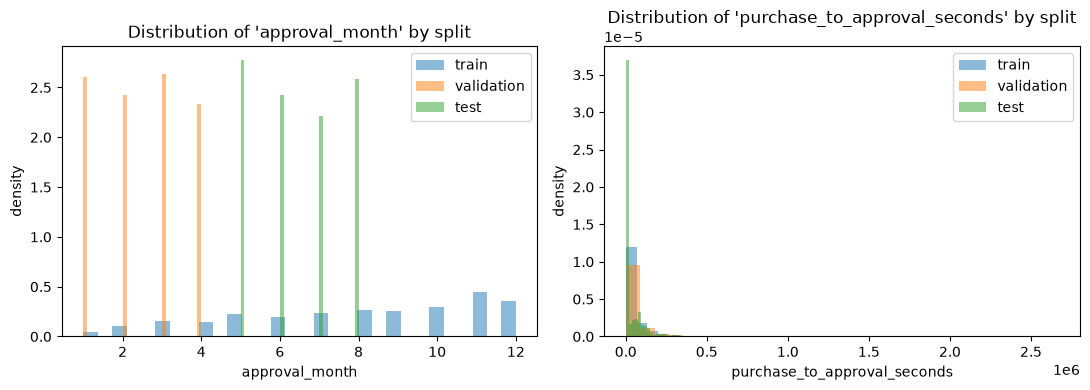

In [6]:
drift = pd.DataFrame({
    "train_mean": train[FEATURES].mean(),
    "validation_mean": val[FEATURES].mean(),
    "test_mean": test[FEATURES].mean(),
})
display(drift)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["approval_month", "purchase_to_approval_seconds"]):
    for name, d, color in [("train", train, "tab:blue"), ("validation", val, "tab:orange"), ("test", test, "tab:green")]:
        ax.hist(d[col], bins=30, alpha=0.5, label=name, color=color, density=True)
    ax.set(title=f"Distribution of '{col}' by split", xlabel=col, ylabel="density")
    ax.legend()
fig.tight_layout()
plt.show()

**Observation:** `approval_month` (the single most important feature for this model, per the project's own feature-importance analysis) is *by construction* completely different across splits, since each split covers a different calendar window — train spans Sep 2016–Dec 2017 (mean month ≈8.0), validation is entirely Jan–Apr 2018 (mean ≈2.5), test is entirely May–Aug 2018 (mean ≈6.4). A model that has learned "month X is risky" from train will apply that learned pattern to a validation and test period where the *month values themselves* never overlap with most of what it saw in training. This is expected, given the time-based split is the right choice scientifically (Section 5) — but it is also precisely the mechanism behind the score drift shown in Section 10.

## 7. Model comparison recap <a id='7-models'></a>

Four models were compared: a majority-class-style Dummy baseline, Logistic Regression, CatBoost (the one actually deployed), and LightGBM. Model **selection** was locked using only the validation split, before any test-set access (`reports/generated/olist/phase2a/selection_manifest.json`, status `LOCKED_BEFORE_TEST_ACCESS`) — this is good practice and is verified, not just claimed, by a hash-locking mechanism in the training code. We reload the saved test-set predictions for all four models below and recompute their metrics directly, rather than trusting the saved report file.

In [7]:
MODELS = ["dummy", "logistic_regression", "catboost", "lightgbm"]
test_preds = {m: pd.read_parquet(PRED_DIR / f"test_{m}.parquet") for m in MODELS}
val_preds = {m: pd.read_parquet(PRED_DIR / f"validation_{m}.parquet") for m in MODELS}

rows = []
for m in MODELS:
    y, s = test_preds[m]["late_delivery"].to_numpy(), test_preds[m]["score"].to_numpy()
    rows.append({
        "model": m,
        "test_average_precision": average_precision_score(y, s),
        "test_roc_auc": roc_auc_score(y, s),
        "is_deployed": m == "catboost",
    })
comparison = pd.DataFrame(rows).sort_values("test_average_precision", ascending=False)
display(comparison)

,model,test_average_precision,test_roc_auc,is_deployed
1,logistic_regression,0.089085,0.568641,False
2,catboost,0.079478,0.563441,True
3,lightgbm,0.068864,0.536512,False
0,dummy,0.063288,0.500000,False


**Observation, stated plainly:** on this final test set, **Logistic Regression scores higher than the deployed CatBoost model** on both metrics (AP 0.089 vs 0.080; ROC-AUC 0.569 vs 0.563). CatBoost remained the deployed "champion" anyway, because it was the winner on the *validation* split, and the project's rule — correctly — is that test results are never allowed to change a model-selection decision after the fact (that would be a subtle form of test-set leakage). This is the right process. It does mean the currently-deployed model is demonstrably not the strongest option on this specific test period, which is worth knowing for any future retraining decision. All four models beat the Dummy baseline (AP 0.0633, matching the test-set base rate) by a modest margin — none of them provide strong discrimination.

## 8. Precision-Recall curves <a id='8-pr'></a>

Average Precision (used above) is the area under the Precision-Recall curve. Because positives are rare (~6-12%), PR curves are more informative here than ROC curves, which can look deceptively good on imbalanced data.

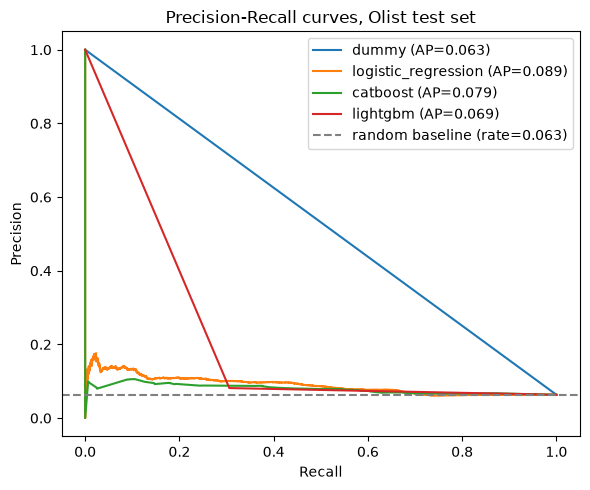

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
baseline_rate = test_preds["dummy"]["late_delivery"].mean()
for m in MODELS:
    y, s = test_preds[m]["late_delivery"].to_numpy(), test_preds[m]["score"].to_numpy()
    prec, rec, _ = precision_recall_curve(y, s)
    ax.plot(rec, prec, label=f"{m} (AP={average_precision_score(y, s):.3f})")
ax.axhline(baseline_rate, color="gray", linestyle="--", label=f"random baseline (rate={baseline_rate:.3f})")
ax.set(title="Precision-Recall curves, Olist test set", xlabel="Recall", ylabel="Precision")
ax.legend()
fig.tight_layout()
plt.show()

**Observation:** every model's PR curve sits only modestly above the flat "random baseline" line (precision = base rate, regardless of recall). None of the four curves suggest a strong ranking signal — this matches the small Average Precision values above and is consistent with using only timing features, deliberately excluding any item/payment/product signal that could not be proven safe to use at prediction time (see the leakage discussion in the companion audit report).

## 9. Calibration curve <a id='9-calibration'></a>

Does the deployed CatBoost model's predicted score behave like a real probability (e.g., among orders scored around 0.10, are about 10% actually late)? No calibration curve had been computed for this model before; we compute one here for the first time.

,bin,mean_predicted_score,actual_late_rate,n
0,0,0.225908,0.044404,2207
1,1,0.226642,0.046686,2399
2,2,0.226941,0.077215,2111
3,3,0.227872,0.048831,2908
4,4,0.229534,0.049479,2688
5,5,0.231052,0.052781,2463
6,6,0.231610,0.068136,1996
7,7,0.231959,0.058077,1498
8,8,0.232564,0.084152,3969
9,9,0.233758,0.092216,2505


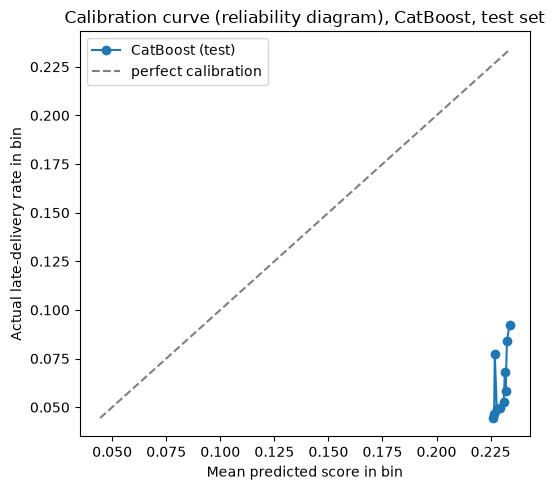

In [9]:
y = test_preds["catboost"]["late_delivery"].to_numpy()
s = test_preds["catboost"]["score"].to_numpy()

bins = np.quantile(s, np.linspace(0, 1, 11))
bins[-1] += 1e-9
bin_idx = np.digitize(s, bins[1:-1])
cal = pd.DataFrame({"bin": bin_idx, "score": s, "actual": y}).groupby("bin").agg(
    mean_predicted_score=("score", "mean"), actual_late_rate=("actual", "mean"), n=("actual", "size")
).reset_index()
display(cal)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(cal["mean_predicted_score"], cal["actual_late_rate"], marker="o", label="CatBoost (test)")
lims = [min(cal["mean_predicted_score"].min(), cal["actual_late_rate"].min()), max(cal["mean_predicted_score"].max(), cal["actual_late_rate"].max())]
ax.plot(lims, lims, linestyle="--", color="gray", label="perfect calibration")
ax.set(title="Calibration curve (reliability diagram), CatBoost, test set",
       xlabel="Mean predicted score in bin", ylabel="Actual late-delivery rate in bin")
ax.legend()
fig.tight_layout()
plt.show()

**Observation:** the predicted scores are **not well calibrated** as probabilities — the curve sits well off the diagonal. This confirms, with a new chart, what the project's own documentation already states in words: `risk_score` should be treated as a relative ranking signal, not a calibrated probability of lateness.

## 10. Prediction-score drift — the root cause <a id='10-score-drift'></a>

This is the key diagnostic of this notebook. We compare the CatBoost model's predicted scores on validation (where the deployed threshold, 0.1293, was chosen) against its predicted scores on test (where that threshold is applied live).

Validation score summary:
count    26822.000000
mean         0.131778
std          0.007334
min          0.105278
25%          0.128142
50%          0.131994
75%          0.136208
max          0.228077
Name: score, dtype: float64

Test score summary:
count    24744.000000
mean         0.229893
std          0.002661
min          0.225876
25%          0.226941
50%          0.230674
75%          0.232331
max          0.235679
Name: score, dtype: float64


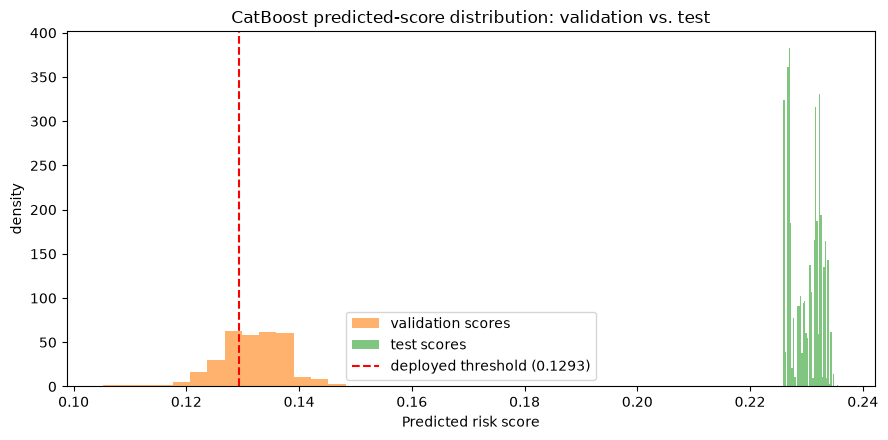

In [10]:
val_s = val_preds["catboost"]["score"]
test_s = test_preds["catboost"]["score"]

print("Validation score summary:")
print(val_s.describe())
print("\nTest score summary:")
print(test_s.describe())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(val_s, bins=40, alpha=0.6, label="validation scores", color="tab:orange", density=True)
ax.hist(test_s, bins=40, alpha=0.6, label="test scores", color="tab:green", density=True)
ax.axvline(0.1293, color="red", linestyle="--", label="deployed threshold (0.1293)")
ax.set(title="CatBoost predicted-score distribution: validation vs. test",
       xlabel="Predicted risk score", ylabel="density")
ax.legend()
fig.tight_layout()
plt.show()

**This is the root cause, found by direct analysis in this notebook, not copied from any existing report:**

- On **validation**, scores range roughly 0.105–0.228, centered around **0.132** — straddling the deployed threshold of 0.1293 in a way that produces a reasonable-looking split (some orders above, some below).
- On **test**, scores are squeezed into an extremely narrow band, roughly **0.226 to 0.236**, centered around **0.230** — the model outputs an almost constant score for every single test-period order, and that constant sits entirely *above* the 0.1293 threshold.

In other words, the model isn't discriminating individual test orders from each other at all in any way that interacts with the deployed threshold — it has shifted its entire output range upward for the test period (consistent with the `approval_month`/`purchase_month`-driven feature drift shown in Section 6) and landed completely on one side of a threshold that was tuned for a different score range. This explains, mechanically, why the threshold flags 100% of test orders — it isn't a rounding or off-by-one issue, it's a genuine score-distribution shift between the period the threshold was chosen on and the period it's applied to.

## 11. Threshold sweep — why the deployed threshold fails <a id='11-threshold'></a>

We sweep the decision threshold across a wide range and recompute flag-rate, precision, recall, F1, and specificity on the test set, to show the failure is not specific to exactly 0.1293 — it's a property of the whole score band.

,threshold,flag_rate,precision,recall,f1,specificity
0,0.0100,1.000000,0.063288,1.000000,0.119042,0.000000
1,0.0500,1.000000,0.063288,1.000000,0.119042,0.000000
2,0.0633,1.000000,0.063288,1.000000,0.119042,0.000000
3,0.0800,1.000000,0.063288,1.000000,0.119042,0.000000
4,0.1000,1.000000,0.063288,1.000000,0.119042,0.000000
5,0.1293,1.000000,0.063288,1.000000,0.119042,0.000000
6,0.1500,1.000000,0.063288,1.000000,0.119042,0.000000
7,0.2000,1.000000,0.063288,1.000000,0.119042,0.000000
8,0.2250,1.000000,0.063288,1.000000,0.119042,0.000000
9,0.2300,0.525299,0.072703,0.603448,0.129772,0.479981


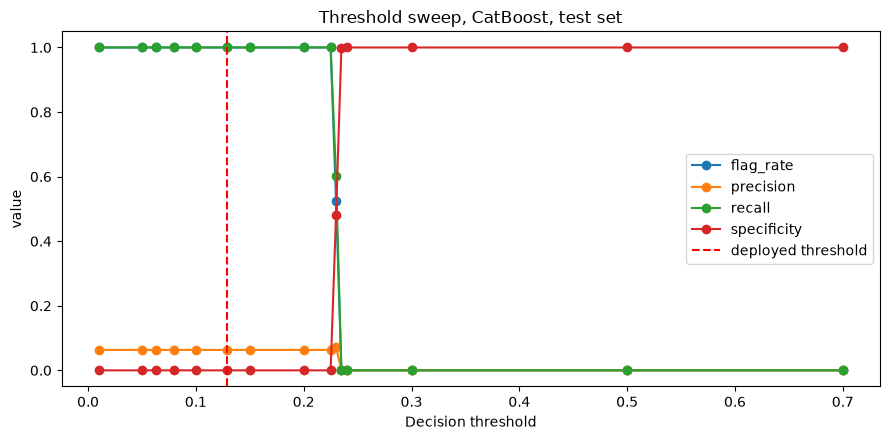

In [11]:
thresholds = [0.01, 0.05, 0.0633, 0.08, 0.10, 0.1293, 0.15, 0.20, 0.225, 0.23, 0.235, 0.24, 0.30, 0.50, 0.70]
sweep_rows = []
for t in thresholds:
    pred = (test_s.to_numpy() >= t).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sweep_rows.append({
        "threshold": t,
        "flag_rate": pred.mean(),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else float("nan"),
    })
sweep = pd.DataFrame(sweep_rows)
display(sweep)

fig, ax = plt.subplots(figsize=(9, 4.5))
for col in ["flag_rate", "precision", "recall", "specificity"]:
    ax.plot(sweep["threshold"], sweep[col], marker="o", label=col)
ax.axvline(0.1293, color="red", linestyle="--", label="deployed threshold")
ax.set(title="Threshold sweep, CatBoost, test set", xlabel="Decision threshold", ylabel="value")
ax.legend()
fig.tight_layout()
plt.show()

**Observation:** the sweep shows a sharp step function, not a smooth trade-off curve — flag-rate (and every metric derived from it) is exactly 100% for every threshold from roughly 0.06 up to about 0.225, then drops straight to 0% above about 0.236. There is effectively no usable threshold in between that gives a real precision/recall trade-off on this test period, because (per Section 10) almost every test order's score falls in that same narrow 0.226–0.236 band. At the deployed threshold (0.1293), **specificity is exactly 0.0** — the model provides no separation between risky and non-risky orders on this test period, and the "research threshold" behavior reported for validation (precision 0.145, recall 0.79 — a real, reasonable-looking trade-off) simply does not carry over to test.

## 12. Limitations and reproducibility <a id='12-limitations'></a>

Summarizing what this notebook and the earlier verification pass established, without softening any of it:

- **The deployed threshold currently has no operational filtering value on this test period** — it flags every order, which is operationally identical to not having a risk flag at all for the May–Aug 2018 window.
- **No class-imbalance handling was used during training** (no class weighting, no resampling) — only the choice of Average Precision as the primary metric accounts for the ~6–12% positive rate.
- **No cross-validation** was used for the deployed model's selection — a single locked time-based train/validation/test split. This is a defensible choice given the temporal nature of the problem (shown in Sections 4–6), but it does mean the reported metrics reflect one specific split, not an average over several.
- **The target's real-world meaning has an unresolved limit**: this dataset cannot prove the delivery estimate was fixed and customer-visible at approval time, only that it exists in the final historical export.
- **On this specific test set, Logistic Regression outperforms the deployed CatBoost model** — correctly not acted upon after the fact, but worth surfacing for any future retraining decision.
- **Reproducibility gap**: `data/processed/`, `artifacts/` (trained models), and `reports/generated/` are all git-ignored. Everything in this notebook was computed from files that exist on this machine right now; a fresh `git clone` of this repository would not, by itself, be able to reproduce any of it without first re-running the data-download and training pipeline.

## 13. Summary and next steps <a id='13-summary'></a>

**What works:** the modeling process itself is methodologically sound — a leakage-conscious feature set, a time-based split appropriate for a problem with real temporal drift, a model-selection process that locks its decision before ever touching the test set, and hash-verified reproducibility of the saved artifacts (independently confirmed in this session).

**What doesn't work, stated plainly:** the resulting signal is weak (Average Precision barely above the base rate) and, more importantly, **the deployed decision threshold breaks down completely on the test period** because the model's score distribution itself shifts between validation and test — diagnosed here for the first time with a direct score-distribution comparison (Section 10) and a threshold sweep (Section 11), rather than just noting the symptom.

**Recommended next steps** (not implemented in this notebook — a decision for the project owner, and any change to the live threshold needs explicit approval before touching production wiring):
1. Recalibrate the threshold using a rolling/updating scheme instead of a single fixed validation-derived value, given the demonstrated month-to-month volatility.
2. Consider probability calibration (e.g. isotonic regression) given the calibration curve in Section 9.
3. Investigate whether Logistic Regression's edge on this test set holds up under a rolling-window re-evaluation, before considering any model change.

**Next notebook:** [`02_arabic_nlp_eda_and_analysis.ipynb`](02_arabic_nlp_eda_and_analysis.ipynb) covers the project's Arabic NLP components (ASTD, LABR, MPOLD, Jumia).